In [6]:
!pip install -U pandas numpy scikit-learn shap matplotlib openpyxl



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [7]:
import os, pandas as pd

TCRI_PATH = 'tcri.csv'
FIN_PATH  = 'ratios_filled_with_gics_category.csv'
OUT_DIR   = 'outputs/qrt_model'

os.makedirs(OUT_DIR, exist_ok=True)
os.environ['OUT_DIR'] = OUT_DIR

print('tcri.csv exists?', os.path.exists(TCRI_PATH))
print('ratios_filled_with_gics_category.csv exists?', os.path.exists(FIN_PATH))


tcri.csv exists? True
ratios_filled_with_gics_category.csv exists? True


In [8]:
import os, pandas as pd
OUT_DIR = os.environ['OUT_DIR']

!python merge_tcri_and_ratios.py \
  --tcri "$TCRI_PATH" \
  --ratios "$FIN_PATH" \
  --ratios-date-format "%Y/%m" \
  --dedup-ratios \
  --out "$OUT_DIR/merged.csv"

merged = pd.read_csv(f"{OUT_DIR}/merged.csv", parse_dates=['mdate'])
merged.head()


[INFO] Dropped 88 duplicate rows from ratios data based on (id,date)
[INFO] Merged shape: (6383, 19). Saved to /Users/chieh.1227/repo/ML/outputs/qrt_model/merged.csv


,coid,mdate,tcri,scr,xcdt,company,WorkingCapital_TotalAssets,RetainedEarnings_TotalAssets,CashFlow_TotalDebt,TotalDebt_TotalAssets,CurrentRatio,stock_prefix,WorkingCapital_TotalAssets_miss,RetainedEarnings_TotalAssets_miss,CashFlow_TotalDebt_miss,TotalDebt_TotalAssets_miss,CurrentRatio_miss,產業別,GICS_Category
0,1103,2014-12-01,6,400.0,NaN,1103 嘉泥,0.248834,0.222521,0.031686,0.355758,1.573942,11,0,0,0,0,0,水泥工業,9
1,1103,2015-12-01,6,432.0,NaN,1103 嘉泥,0.288490,0.266805,0.022494,0.396789,2.079358,11,0,0,0,0,0,水泥工業,9
2,1103,2016-12-01,6,371.0,NaN,1103 嘉泥,0.251213,0.276883,0.039433,0.332750,1.751954,11,0,0,0,0,0,水泥工業,9
3,1103,2017-12-01,6,330.0,NaN,1103 嘉泥,0.214906,0.277971,0.043575,0.277508,1.595351,11,0,0,0,0,0,水泥工業,9
4,1103,2018-12-01,6,331.0,NaN,1103 嘉泥,0.222120,0.264199,-0.055883,0.297109,1.501782,11,0,0,0,0,0,水泥工業,9


In [9]:

import os, json
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor

from src.data_prep import load_and_prepare, create_label_next_period, time_split, detect_feature_columns
from src.metrics import best_f1_threshold, threshold_at_precision
from src.reporting import aggregate_slice_metrics, evaluate_predictions, prepare_prediction_frame, save_artifacts
from src.explain import run_shap_for_model

CSV_PATH = os.path.join(os.environ['OUT_DIR'], 'merged.csv')
ID_COL = 'coid'
DATE_COL = 'mdate'
TCRI_COL = 'tcri'
GICS_COL = 'GICS_Category'
TAU = 7
HORIZON = 1
train_start, train_end = '2014-01-01', '2021-12-31'
valid_start, valid_end = '2022-01-01', '2022-12-31'
test_start, test_end = '2023-01-01', '2023-12-31'

df = load_and_prepare(CSV_PATH, ID_COL, DATE_COL, None, TCRI_COL)
df = create_label_next_period(df, ID_COL, TCRI_COL, TAU, HORIZON)
train, valid, test = time_split(df, DATE_COL, train_start, train_end, valid_start, valid_end, test_start, test_end)
num_cols, cat_cols = detect_feature_columns(train, ID_COL, DATE_COL, TCRI_COL, categorical_cols=[GICS_COL])

pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

param_grid = [
    {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 3, 'alpha': 0.5},
    {'n_estimators': 600, 'learning_rate': 0.05, 'max_depth': 4, 'alpha': 0.5},
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 3, 'alpha': 0.4},
]

best_model = None
best_score = -np.inf
for params in param_grid:
    reg = GradientBoostingRegressor(loss='quantile', random_state=42, **params)
    pipe = Pipeline([('pre', pre), ('reg', reg)])
    pipe.fit(train[num_cols + cat_cols], train['y'])
    p_valid = np.clip(pipe.predict(valid[num_cols + cat_cols]), 1e-6, 1 - 1e-6)
    score = average_precision_score(valid['y'], p_valid)
    print(f'Params {params} -> PR-AUC(valid)={score:.4f}')
    if score > best_score:
        best_score = score
        best_model = pipe

print(f'[INFO] Best validation PR-AUC: {best_score:.4f}')

valid_features = valid[num_cols + cat_cols]
test_features = test[num_cols + cat_cols]
p_valid_best = np.clip(best_model.predict(valid_features), 1e-6, 1 - 1e-6)
t_f1 = best_f1_threshold(valid['y'].values, p_valid_best)
t_rp = threshold_at_precision(valid['y'].values, p_valid_best, 0.5)
print(f'[INFO] Thresholds: t_f1={t_f1:.4f}, t_at_precision={t_rp:.4f}')

p_test = np.clip(best_model.predict(test_features), 1e-6, 1 - 1e-6)
probs = {
    'raw': pd.Series(p_test, index=test.index, name='raw')
}

metrics = evaluate_predictions(test['y'].values, probs, threshold=t_f1, target_precision=0.5)
metrics['thresholds'] = {'t_f1': t_f1, 't_at_precision': t_rp, 'precision_target': 0.5}
metrics['valid_pr_auc_for_best_params'] = float(best_score)

slice_tables = {
    'quarter': aggregate_slice_metrics(test, probs, 'quarter', threshold=t_f1, target_precision=0.5)
}
if GICS_COL in test.columns:
    slice_tables[GICS_COL] = aggregate_slice_metrics(test, probs, GICS_COL, threshold=t_f1, target_precision=0.5)

feature_names = best_model.named_steps['pre'].get_feature_names_out()
importances = best_model.named_steps['reg'].feature_importances_
feature_weights = pd.DataFrame({
    'feature': feature_names,
    'coefficient': importances,
    'abs_coefficient': np.abs(importances),
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

preds = prepare_prediction_frame(test, ID_COL, DATE_COL, probs)
save_artifacts(preds, metrics, feature_weights, slice_tables, os.environ['OUT_DIR'])

print(json.dumps(metrics['raw'], indent=2))
print('Artifacts saved to', os.environ['OUT_DIR'])

dense_train = best_model.named_steps['pre'].transform(train[num_cols + cat_cols])
dense_test = best_model.named_steps['pre'].transform(test[num_cols + cat_cols])
run_shap_for_model(
    fitted_model=best_model.named_steps['reg'],
    X_train=dense_train,
    X_test=dense_test,
    feature_names=feature_weights['feature'].tolist(),
    model_name='qrt_model'
)



Params {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 3, 'alpha': 0.5} -> PR-AUC(valid)=0.3490
Params {'n_estimators': 600, 'learning_rate': 0.05, 'max_depth': 4, 'alpha': 0.5} -> PR-AUC(valid)=0.3490
Params {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 3, 'alpha': 0.4} -> PR-AUC(valid)=0.3490
[INFO] Best validation PR-AUC: 0.3490
[INFO] Thresholds: t_f1=0.0000, t_at_precision=0.5000
{
  "pr_auc": 0.28917609046849757,
  "roc_auc": 0.5,
  "f1": 0.44862155388471175,
  "precision": 0.28917609046849757,
  "recall": 1.0,
  "brier": 0.2891755121173166,
  "logloss": 3.9951160418026253,
  "ece": 0.2891750904684976,
  "threshold": 1e-06,
  "recall_at_p>=0.50": 0.0,
  "threshold_at_p>=0.50": 0.5
}
Artifacts saved to outputs/qrt_model


In [10]:
import os, json, pandas as pd
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/qrt_model')
with open(f'{OUT_DIR}/metrics_summary.json','r',encoding='utf-8') as f:
    metrics_summary = json.load(f)
pd.DataFrame({k:v for k,v in metrics_summary.items() if isinstance(v,dict) and 'pr_auc' in v}).T


,slice,n,pos,raw.pr_auc,raw.roc_auc,raw.f1,raw.precision,raw.recall,raw.brier,raw.logloss,raw.ece,raw.threshold,raw.recall_at_p>=0.50,raw.threshold_at_p>=0.50
0,quarter=2023Q4,619,179,0.289176,0.5,0.448622,0.289176,1.0,0.289176,3.995116,0.289175,0.000001,0.0,0.5


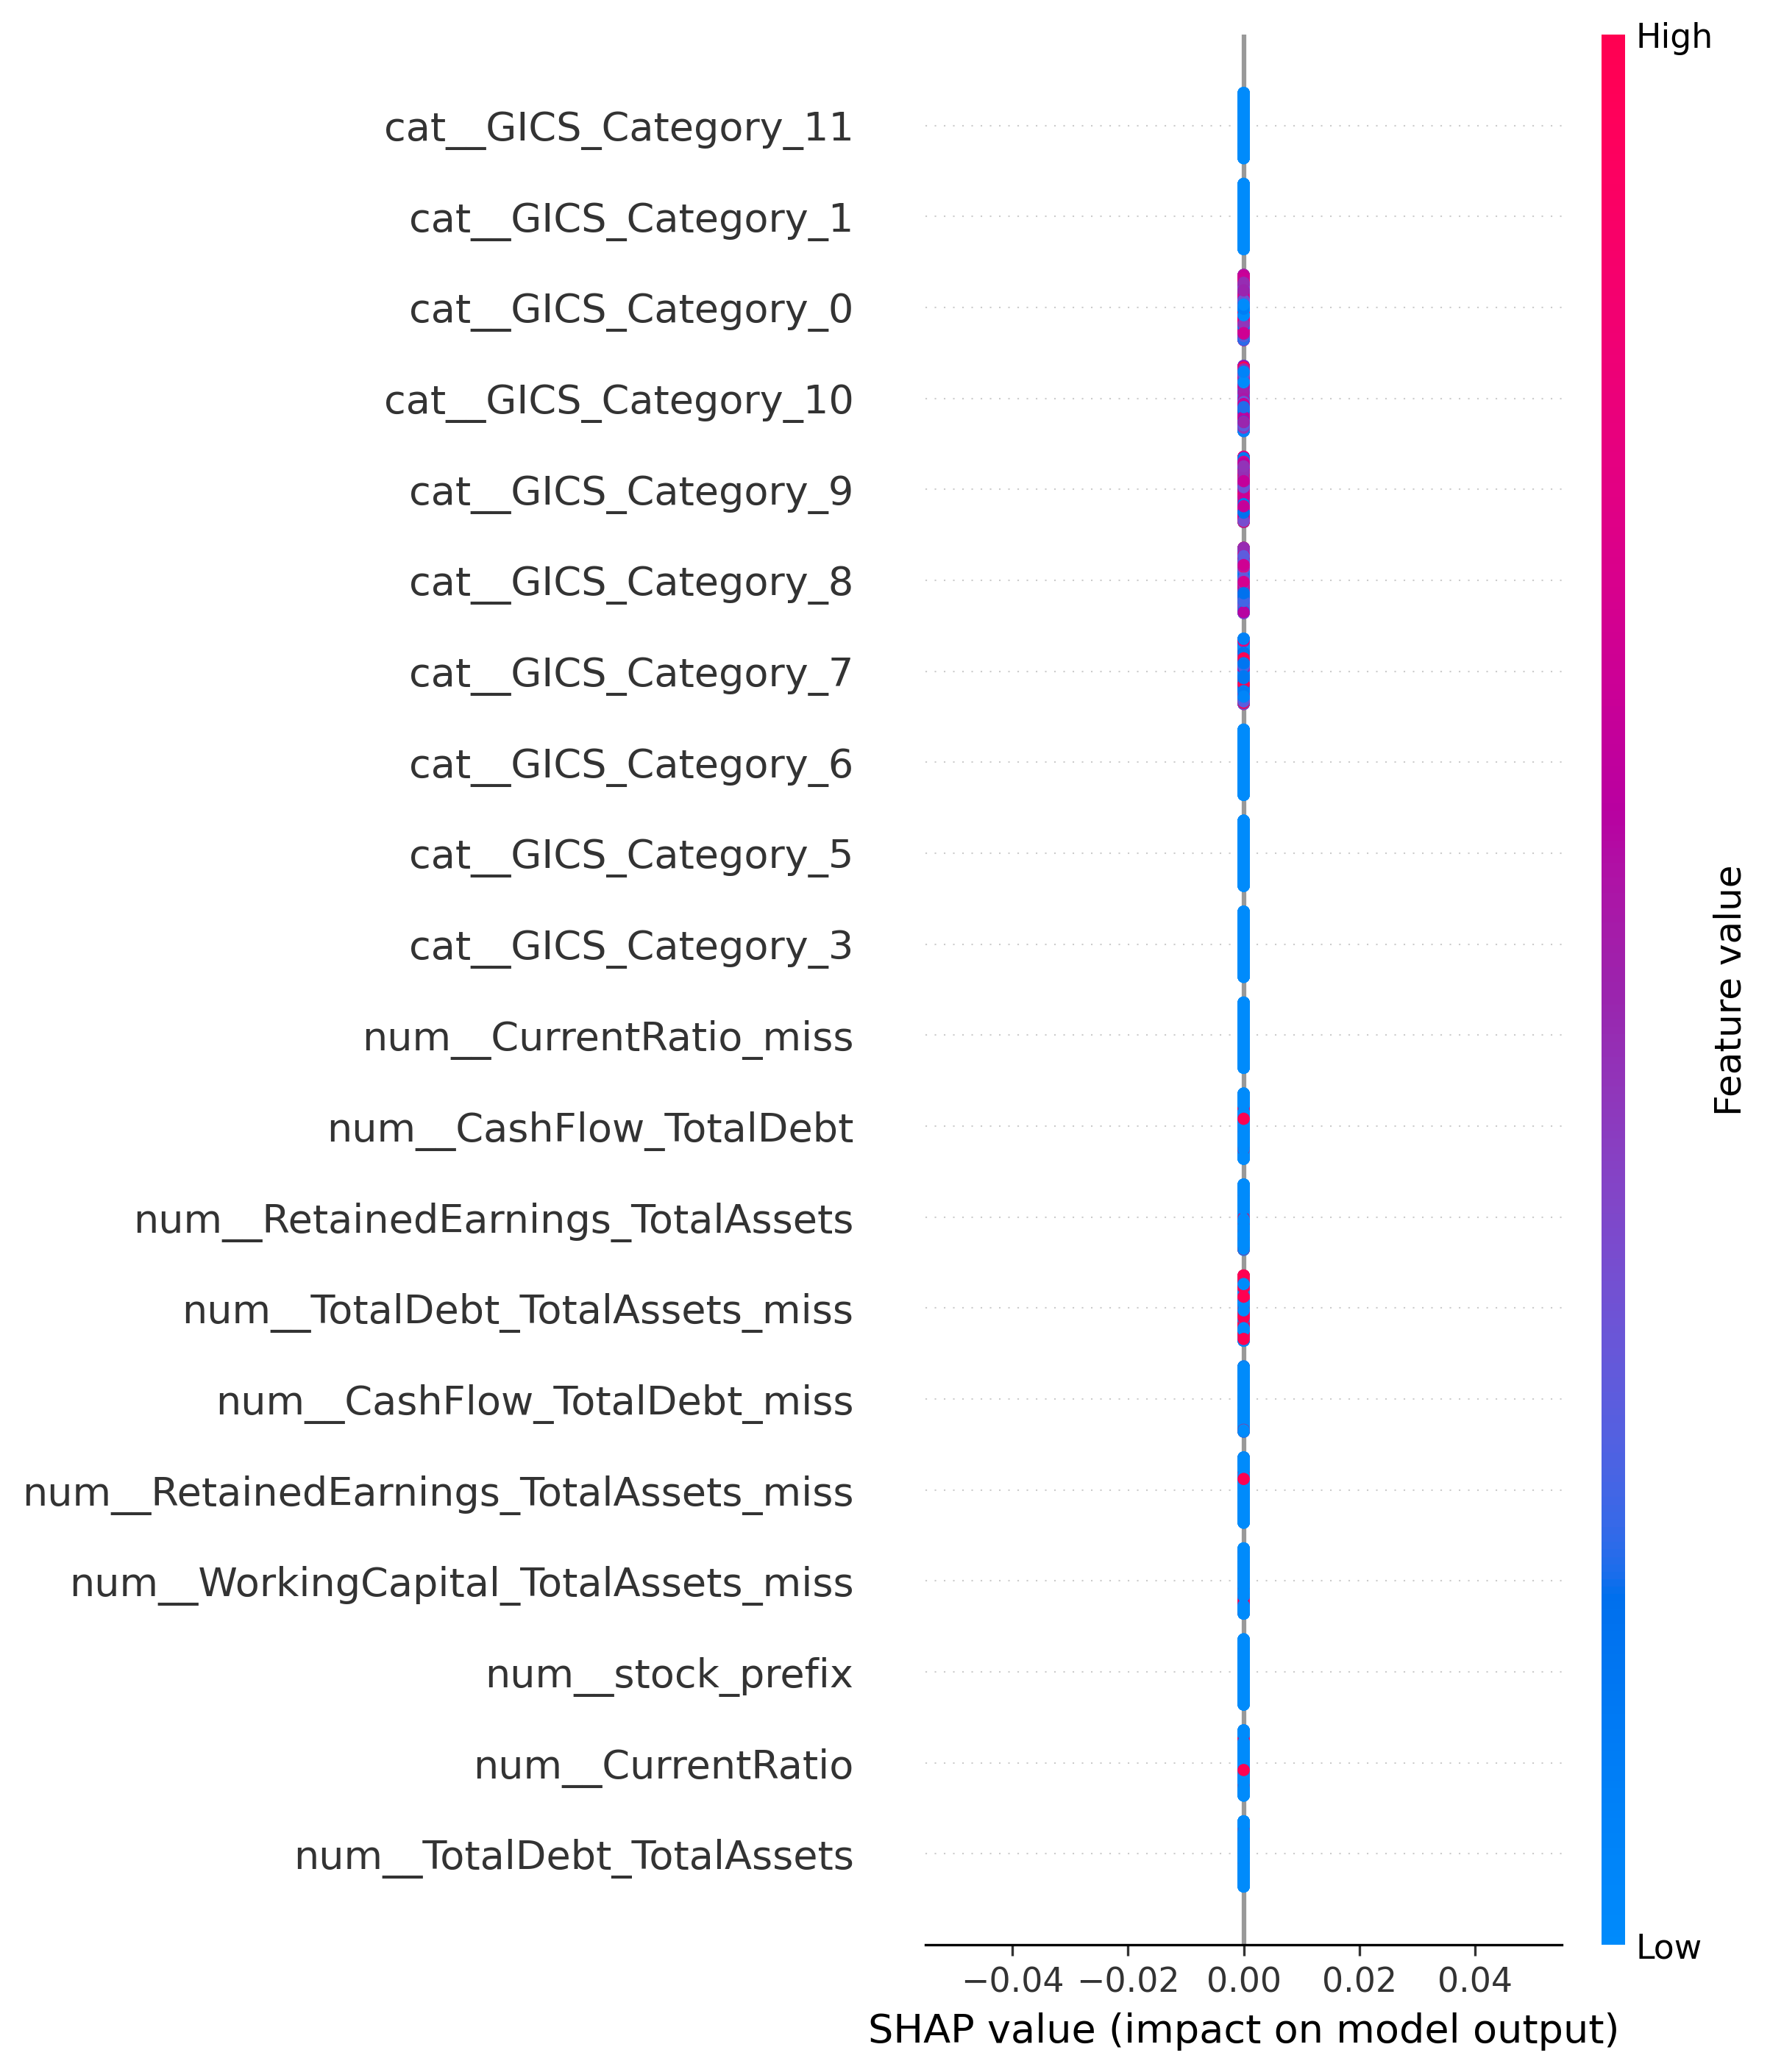

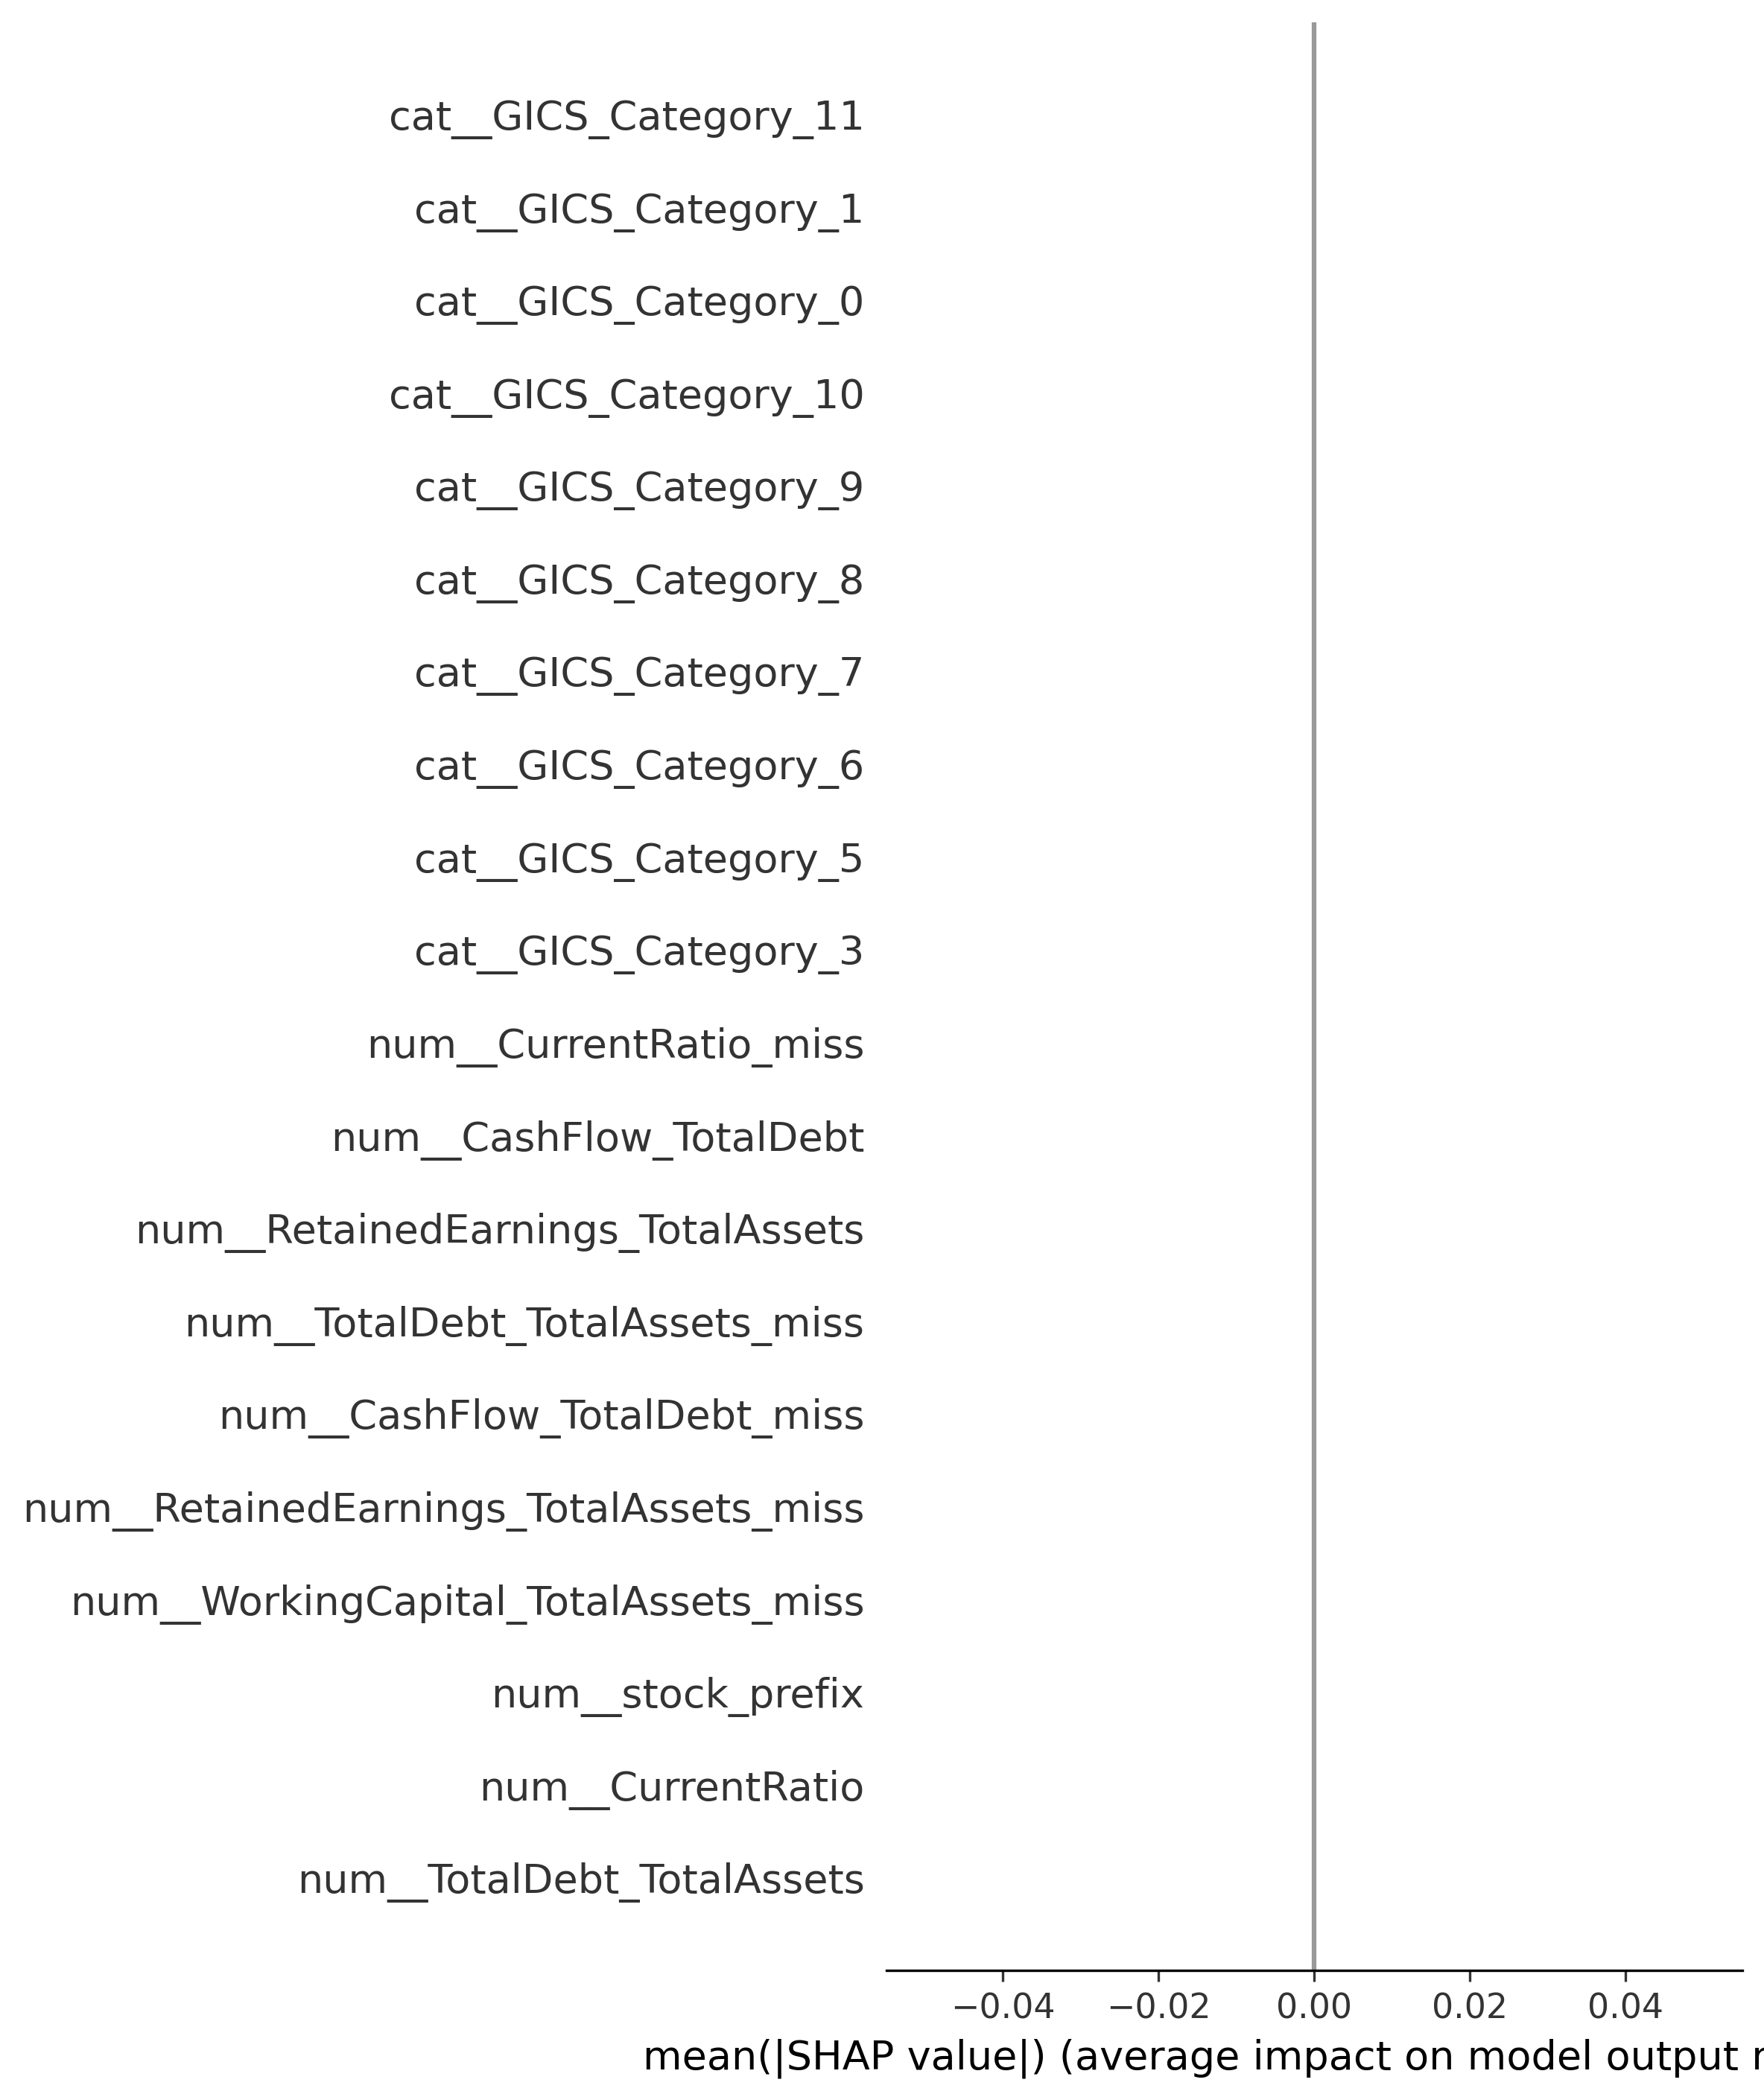

In [1]:
from IPython.display import Image
display(Image(filename='outputs/plots/shap_summary_qrt_model.png'))
display(Image(filename='outputs/plots/shap_bar_qrt_model.png'))


In [5]:
import os, json, pandas as pd
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/qrt_model')
with open(f'{OUT_DIR}/metrics_summary.json','r',encoding='utf-8') as f:
    metrics_summary = json.load(f)
pd.DataFrame({k:v for k,v in metrics_summary.items() if isinstance(v,dict) and 'pr_auc' in v}).T


,pr_auc,roc_auc,f1,precision,recall,brier,logloss,ece,threshold,recall_at_p>=0.50,threshold_at_p>=0.50
raw,0.289176,0.5,0.448622,0.289176,1.0,0.289176,3.995116,0.289175,0.000001,0.0,0.5


In [7]:
import os, pandas as pd
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/qrt_model')
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f'{OUT_DIR}/predictions_test.csv')
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
confusion = pd.crosstab(preds['y_true'], preds['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
confusion = confusion.reindex(index=[0,1], columns=[0,1], fill_value=0)
confusion


y_pred,0,1
y_true,,
0,0,440
1,0,179
